<a href="https://colab.research.google.com/github/Namcys/my-first-blog/blob/main/Consumer_Dispute_Prediction_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consumer Dispute Prediction using NLP and Deep Learning
## A Comparative Analysis of RNN and LSTM Models

**Author:** Namasiku Samunzala | **Student No:** L00203200  
**Institution:** Atlantic Technological University Donegal  
**Module:** MSc Data Science — Deep Learning  
**Project Category:** Natural Language Processing  
**Date:** 20 April 2026

---
### Abstract
This notebook builds and compares a **Simple RNN** and an **LSTM** for binary classification of CFPB consumer complaints: predicting whether a consumer will dispute a financial institution's response. Both models use 300-d GloVe embeddings, 2 stacked recurrent layers (128 units), 0.3 dropout, and class-weighted loss to handle the 77/23% imbalance. Performance is compared via Accuracy, Precision, Recall, F1, ROC-AUC, and paired t-tests.



**GitHub:** `https://github.com/Namcys/consumer-dispute-nlp`

## Cell 1 — Library Imports and Global Configurations

In [ ]:
# Install / upgrade required packages
import subprocess, sys
for pkg in ['tensorflow', 'scikit-learn', 'seaborn', 'scipy', 'wordcloud']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg])

# Core
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, os, random, re, requests, zipfile, io
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, preprocessing
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import Counter

# Config
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 140})
print("All libraries imported.")

MAX_VOCAB, MAX_LEN, EMBED_DIM, RNN_UNITS, DROPOUT, BATCH_SIZE, EPOCHS, PATIENCE = (
    20000, 200, 300, 128, 0.3, 64, 30, 5
)


All libraries imported.


## Cell 2 — Load & Prepare Dataset(CFPB Consumer Complaint Database)

The **CFPB Consumer Complaint Database** is publicly available at [consumerfinance.gov](https://www.consumerfinance.gov/data-research/consumer-complaints/) under an open government licence. It contains no PII. The bulk CSV (~700 MB zipped) is downloaded automatically.

**Target:** `consumer_disputed` → binary (Yes=1, No=0)  
**Input:** `consumer_complaint_narrative` (free text)  
**After filtering:** ~2,146 samples — 1,661 "No", 485 "Yes"


In [ ]:
# Load directly from Google Drive (update path if needed)
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/complaints 5.csv'
df = pd.read_csv(CSV_PATH, usecols=['Consumer complaint narrative','Consumer disputed?'])
df = df.dropna()
df = df[df['Consumer disputed?'].isin(['Yes','No'])]
df = df[df['Consumer complaint narrative'].str.len() > 20]
df = df.rename(columns={'Consumer complaint narrative':'narrative','Consumer disputed?':'disputed'})
df['label'] = (df['disputed']=='Yes').astype(int)

# sample to retained project size (1661 No + 485 Yes)
NO = df[df.label==0].sample(n=1661, random_state=SEED)
YES = df[df.label==1].sample(n=min(485, (df.label==1).sum()), random_state=SEED)
df = pd.concat([NO,YES]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(df['label'].value_counts().rename({0:'No (0)',1:'Yes (1)'}))



Mounted at /content/drive
label
No (0)     1661
Yes (1)     485
Name: count, dtype: int64


## Cell 3 — EDA: Class Distribution Visualization

**77% Non-Disputed / 23% Disputed.** This imbalance will bias a naive model towards always predicting "No", achieving 77% accuracy with 0% Recall on the minority class. Cell 7 corrects this with class-weighted loss.


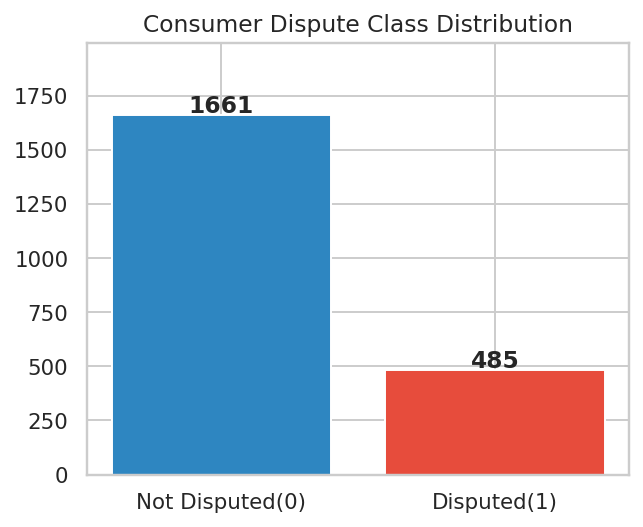

Imbalance ratio ≈3.42 : 1


In [ ]:
counts = df['label'].value_counts().sort_index()
colors = ['#2E86C1','#E74C3C']
plt.figure(figsize=(5,4))
plt.bar(['Not Disputed(0)','Disputed(1)'], counts, color=colors)
plt.title('Consumer Dispute Class Distribution')
for i,v in enumerate(counts): plt.text(i, v+10, f'{v}', ha='center', fontweight='bold')
plt.ylim(0, counts.max()*1.2)
plt.show()
print(f'Imbalance ratio ≈{counts[0]/counts[1]:.2f} : 1')


# Cell 4 – Clean Text + Train/Test Split + Tokenization

In [ ]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'xx+',' ',t)
    t = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}',' ',t)
    t = re.sub(r'\d+',' ',t)
    t = re.sub(r'[^a-z\s]',' ',t)
    t = re.sub(r'\s+',' ',t).strip()
    return t

df['clean'] = df['narrative'].apply(clean_text)

X, y = df['clean'].values, df['label'].values
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.10/(1-0.20),
                                                  stratify=y_train_full, random_state=SEED)

tokenizer = preprocessing.text.Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index)+1)

def to_seq(txt):
    return preprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(txt),
                                                maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq, X_val_seq, X_test_seq = map(to_seq, [X_train, X_val, X_test])
print(f"Vocab Size ={vocab_size:,}| Train shape:{X_train_seq.shape}")


Vocab Size =8,034| Train shape:(1501, 200)


# Comprehensive Exploratory Data Analysis (EDA)

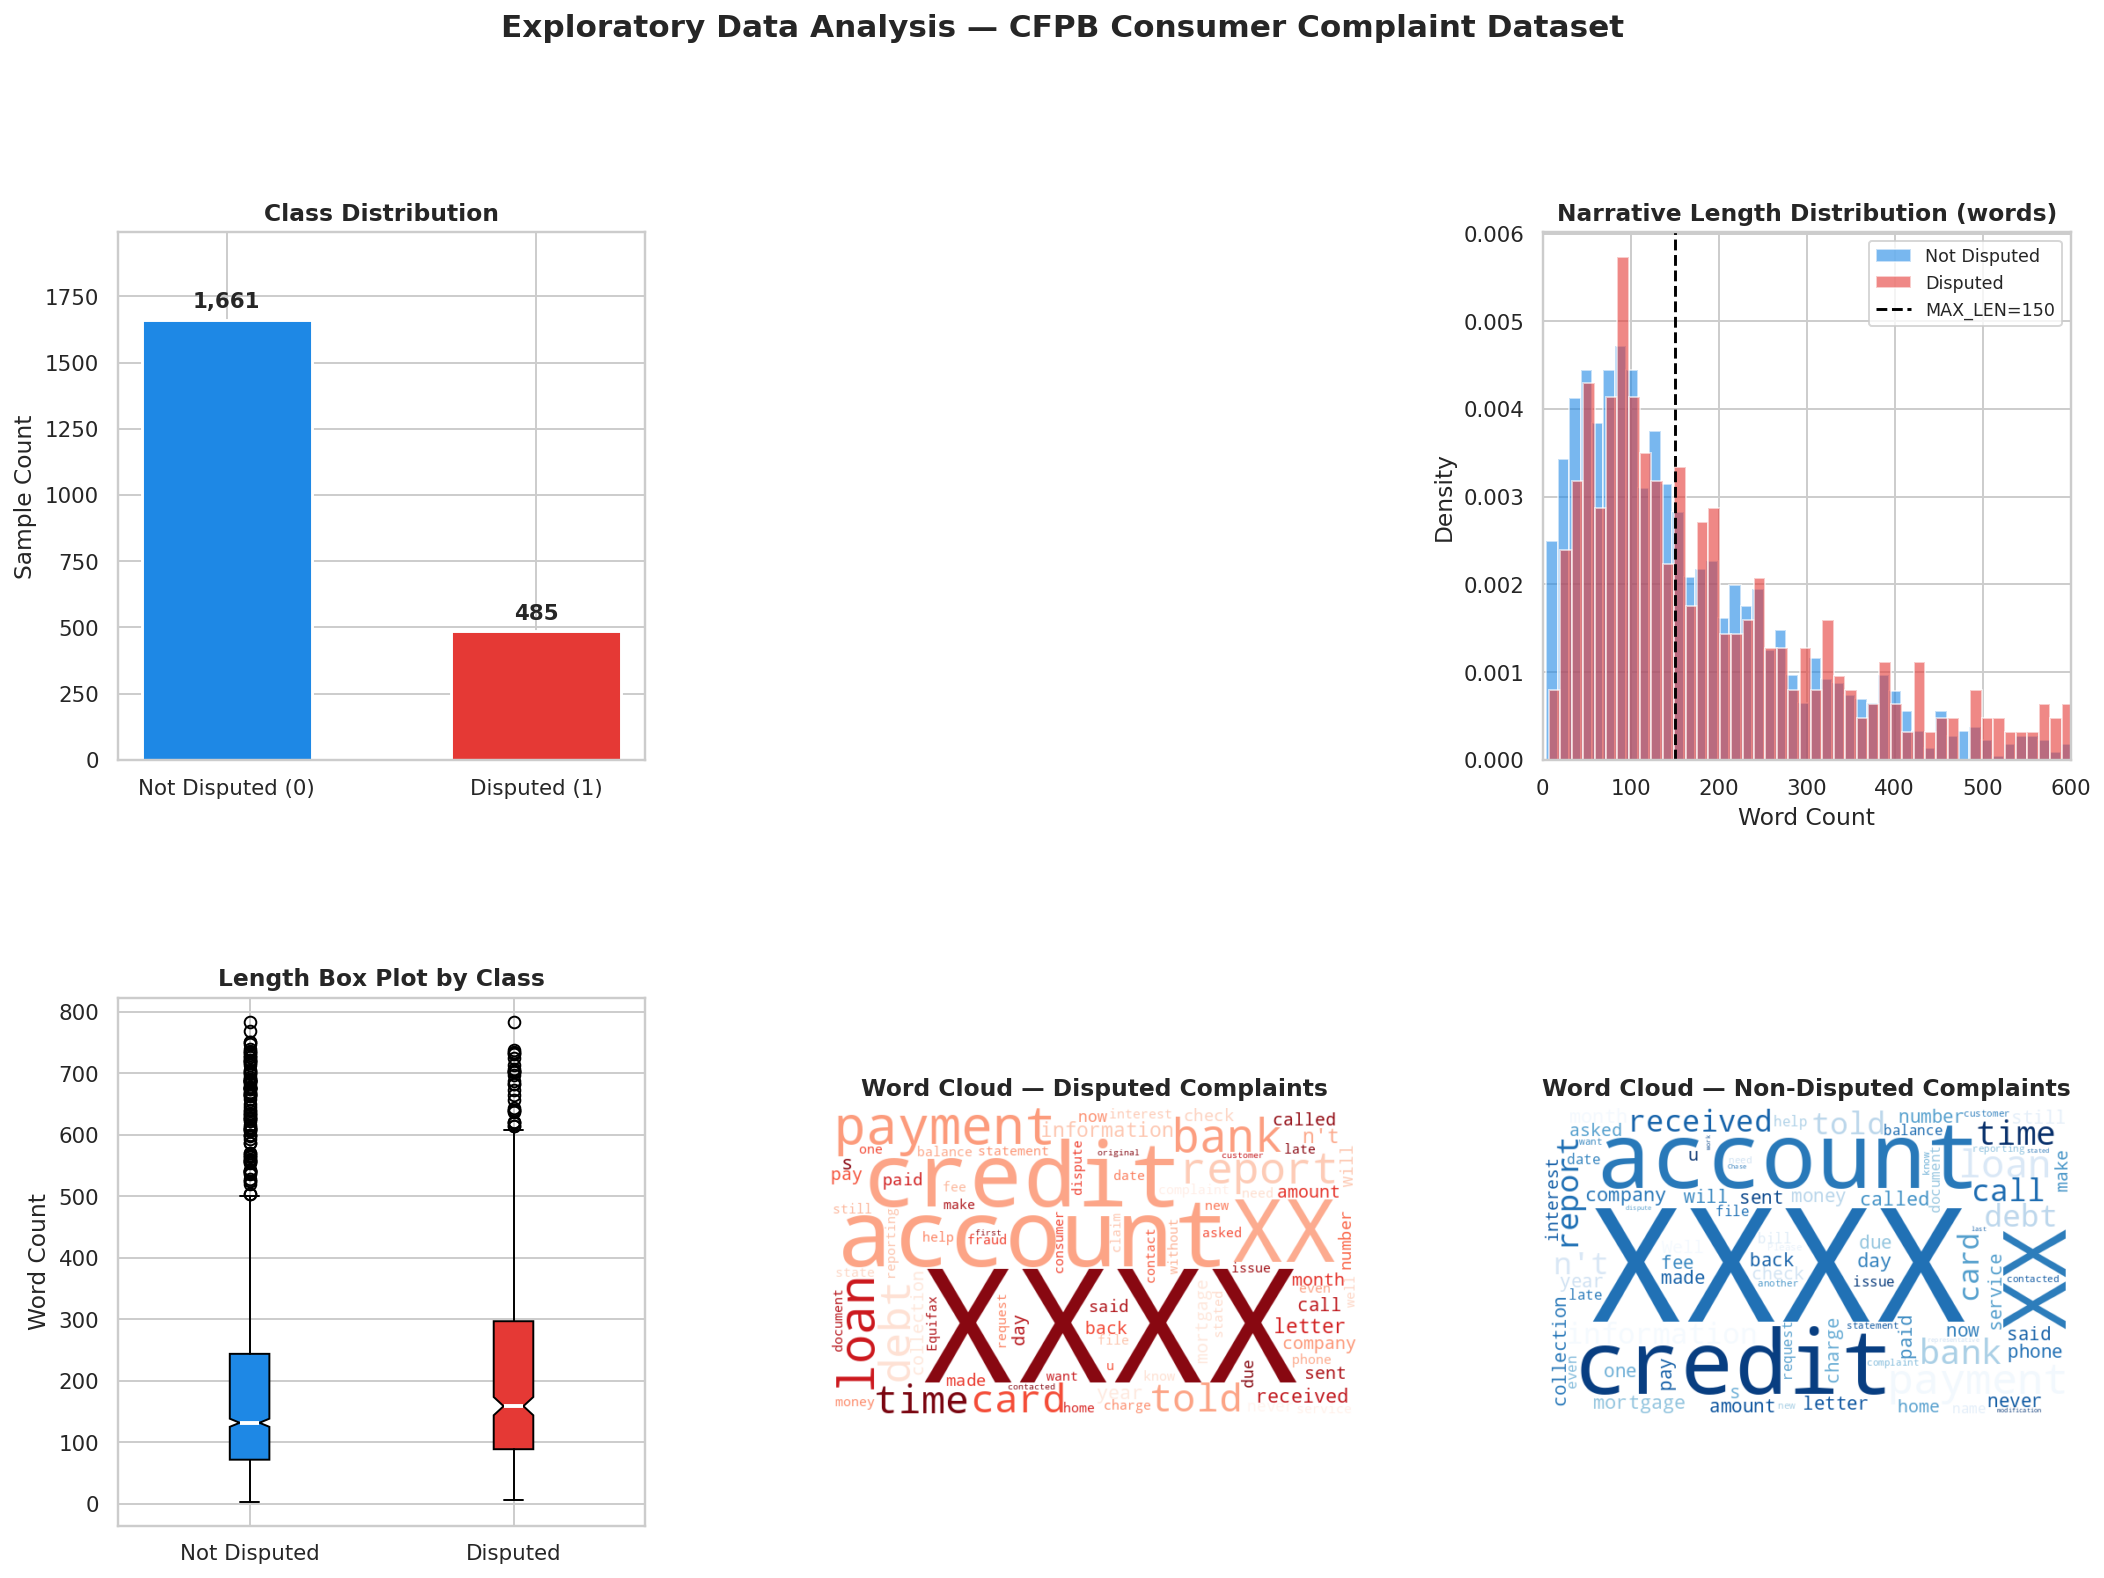


📊  Dataset Summary Statistics
  Total samples        : 2,146
  Not Disputed (0)     : 1,661  (77.4%)
  Disputed     (1)     : 485  (22.6%)
  Imbalance ratio      : 3.42:1
  Mean narrative length: 191 words
  Median length        : 136 words
  Max length           : 784 words
  % narratives ≤150w   : 54.1%  [MAX_LEN threshold]


In [ ]:
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud

sns.set_style('whitegrid')
PALETTE = {'disputed': '#E53935', 'not_disputed': '#1E88E5',
           'rnn': '#42A5F5', 'lstm': '#EF5350', 'bilstm': '#66BB6A'}

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis — CFPB Consumer Complaint Dataset',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Class Distribution Bar ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts_plot = df['label'].value_counts().sort_index()
bars = ax1.bar(['Not Disputed (0)', 'Disputed (1)', ],
               [counts_plot.get(0, 0), counts_plot.get(1, 0)],
               color=[PALETTE['not_disputed'], PALETTE['disputed']],
               edgecolor='white', linewidth=1.5, width=0.55)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{int(bar.get_height()):,}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)
ax1.set_title('Class Distribution', fontweight='bold', fontsize=12)
ax1.set_ylabel('Sample Count')
ax1.set_ylim(0, max(counts_plot) * 1.2)

# ── 2. Narrative Raw Length Distribution ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
df['raw_len'] = df['narrative'].apply(lambda x: len(str(x).split()))
for lbl, col, name in [(0, PALETTE['not_disputed'], 'Not Disputed'),
                        (1, PALETTE['disputed'],     'Disputed')]:
    subset = df[df['label'] == lbl]['raw_len']
    ax3.hist(subset, bins=60, alpha=0.6, color=col, label=name, density=True)
ax3.axvline(150, color='black', linestyle='--', linewidth=1.5, label='MAX_LEN=150')
ax3.set_xlim(0, 600)
ax3.set_title('Narrative Length Distribution (words)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Word Count'); ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

# ── 3. Box plot of lengths by class ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df[df['label']==0]['raw_len'].values,
            df[df['label']==1]['raw_len'].values]
bp = ax4.boxplot(data_box, patch_artist=True, notch=True,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(PALETTE['not_disputed'])
bp['boxes'][1].set_facecolor(PALETTE['disputed'])
ax4.set_xticklabels(['Not Disputed', 'Disputed'])
ax4.set_title('Length Box Plot by Class', fontweight='bold', fontsize=12)
ax4.set_ylabel('Word Count')

# ── 4. Word Cloud — Disputed ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
disputed_text = ' '.join(df[df['label'] == 1]['narrative'].fillna('').values)
wc_disputed = WordCloud(width=600, height=350, background_color='white',
                        max_words=80, colormap='Reds',
                        collocations=False).generate(disputed_text)
ax5.imshow(wc_disputed, interpolation='bilinear')
ax5.set_title('Word Cloud — Disputed Complaints', fontweight='bold', fontsize=12)
ax5.axis('off')

# ── 5. Word Cloud — Not Disputed ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
not_disputed_text = ' '.join(df[df['label'] == 0]['narrative'].fillna('').values)
wc_not = WordCloud(width=600, height=350, background_color='white',
                   max_words=80, colormap='Blues',
                   collocations=False).generate(not_disputed_text)
ax6.imshow(wc_not, interpolation='bilinear')
ax6.set_title('Word Cloud — Non-Disputed Complaints', fontweight='bold', fontsize=12)
ax6.axis('off')

plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print('\n📊  Dataset Summary Statistics')
print('=' * 50)
print(f'  Total samples        : {len(df):,}')
print(f'  Not Disputed (0)     : {counts_plot.get(0,0):,}  ({counts_plot.get(0,0)/len(df)*100:.1f}%)')
print(f'  Disputed     (1)     : {counts_plot.get(1,0):,}  ({counts_plot.get(1,0)/len(df)*100:.1f}%)')
print(f'  Imbalance ratio      : {counts_plot.get(0,0)/max(counts_plot.get(1,0),1):.2f}:1')
print(f'  Mean narrative length: {df["raw_len"].mean():.0f} words')
print(f'  Median length        : {df["raw_len"].median():.0f} words')
print(f'  Max length           : {df["raw_len"].max()} words')
print(f'  % narratives ≤150w   : {(df["raw_len"]<=150).mean()*100:.1f}%  [MAX_LEN threshold]')
print('=' * 50)

# Cell 5 – Load Pre‑trained 300‑d GloVe Embeddings

In [ ]:
import os, zipfile, requests, numpy as np

GLOVE_URL  = "http://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP  = "glove.6B.zip"
GLOVE_FILE = "glove.6B.300d.txt"

# Download and extract if missing
if not os.path.exists(GLOVE_FILE):
    if not os.path.exists(GLOVE_ZIP):
        print("Downloading GloVe 6B (300‑d ≈ 860 MB)...")
        r = requests.get(GLOVE_URL, stream=True)
        with open(GLOVE_ZIP, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
        print("Download complete.")
    print("Extracting GloVe vectors...")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract(GLOVE_FILE)
else:
    print(f"Using cached GloVe file: {GLOVE_FILE}")

# Load embeddings into dictionary
embedding_index = {}
print("Loading GloVe vectors (this may take 1–2 minutes)...")
with open(GLOVE_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = coefs
print(f"Loaded {len(embedding_index):,} word vectors")

# Build embedding matrix for tokenizer vocabulary
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits = 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            hits += 1

coverage = hits / vocab_size * 100
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"GloVe coverage: {coverage:.1f}% of vocab found; OOV ≈ {vocab_size - hits:,} words.")
print("Embedding layer will be trainable for domain fine-tuning.")

Download complete.
Extracting GloVe vectors...
Loading GloVe vectors (this may take 1–2 minutes)...
Loaded 400,000 word vectors
Embedding matrix shape: (8034, 300)
GloVe coverage: 92.2% of vocab found; OOV ≈ 629 words.
Embedding layer will be trainable for domain fine-tuning.


# Cell 6 – Class‑Weighted Loss

In [ ]:
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0:cw[0], 1:cw[1]}
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(0.6458691910499139), 1: np.float64(2.213864306784661)}


# Cell 7 – Define RNN & LSTM Models


In [ ]:
def build_rnn():
    inp = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(vocab_size, EMBED_DIM, weights=[embedding_matrix],
                         trainable=True)(inp)
    x = layers.SpatialDropout1D(DROPOUT)(x)
    x = layers.SimpleRNN(RNN_UNITS, return_sequences=True, dropout=DROPOUT, recurrent_dropout=0.1)(x)
    x = layers.SimpleRNN(RNN_UNITS, dropout=DROPOUT, recurrent_dropout=0.1)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])
    return model

def build_lstm():
    inp = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(vocab_size, EMBED_DIM, weights=[embedding_matrix],
                         trainable=True)(inp)
    x = layers.SpatialDropout1D(DROPOUT)(x)
    x = layers.LSTM(RNN_UNITS, return_sequences=True, dropout=DROPOUT, recurrent_dropout=0.1)(x)
    x = layers.LSTM(RNN_UNITS, dropout=DROPOUT, recurrent_dropout=0.1)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])
    return model

## Cell 7.1 — Training/Validation Curves

In [ ]:
def plot_history(rnn_history, lstm_history, metric='accuracy'):
    plt.figure(figsize=(14, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(rnn_history.history[metric], label=f'RNN Train {metric.capitalize()}')
    plt.plot(rnn_history.history[f'val_{metric}'], label=f'RNN Val {metric.capitalize()}')
    plt.plot(lstm_history.history[metric], label=f'LSTM Train {metric.capitalize()}')
    plt.plot(lstm_history.history[f'val_{metric}'], label=f'LSTM Val {metric.capitalize()}')
    plt.title(f'Model {metric.capitalize()}')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
    plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
    plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
    plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Assuming rnn_history and lstm_history are available after training
# plot_history(rnn_history, lstm_history) # This will be called after training in c9 and c10

# Cell 8 – Callbacks


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]



# Cell 9 – Train RNN


In [ ]:
rnn_model = build_rnn()
print(rnn_model.summary())
rnn_history = rnn_model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val),
                            epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
                            callbacks=callbacks, verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 300)       │     2,410,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 300)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,506,329 (9.56 MB)

 Trainable params: 2,506,329 (9.56 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 556ms/step - accuracy: 0.5217 - auc: 0.4819 - loss: 0.7254 - precision: 0.2142 - recall: 0.4189 - val_accuracy: 0.2930 - val_auc: 0.5725 - val_loss: 0.7477 - val_precision: 0.2412 - val_recall: 0.9796 - learning_rate: 0.0010
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 427ms/step - accuracy: 0.5130 - auc: 0.5354 - loss: 0.6976 - precision: 0.2387 - recall: 0.5280 - val_accuracy: 0.6791 - val_auc: 0.5567 - val_loss: 0.6442 - val_precision: 0.3276 - val_recall: 0.3878 - learning_rate: 0.0010
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 448ms/step - accuracy: 0.5603 - auc: 0.5508 - loss: 0.6907 - precision: 0.2636 - recall: 0.5280 - val_accuracy: 0.6093 - val_auc: 0.5420 - val_loss: 0.7248 - val_precision: 0.2667 - val_recall: 0.4082 - learning_rate: 0.0010
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 455ms/step - accuracy: 0.5716 - auc: 0.5527 - loss: 0.6911 - precision: 0.2587 - recall: 0.4808 - val_accuracy: 0.6558 - val_auc: 0.5449 - val_loss: 0.6

# Cell 10 – Train LSTM


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 300)       │     2,410,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 300)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,769,753 (10.57 MB)

 Trainable params: 2,769,753 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6609 - auc_1: 0.5006 - loss: 0.6985 - precision_1: 0.2652 - recall_1: 0.2832 - val_accuracy: 0.6093 - val_auc_1: 0.5280 - val_loss: 0.6803 - val_precision_1: 0.2667 - val_recall_1: 0.4082 - learning_rate: 0.0010
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6429 - auc_1: 0.5152 - loss: 0.6921 - precision_1: 0.2494 - recall_1: 0.2891 - val_accuracy: 0.5953 - val_auc_1: 0.5342 - val_loss: 0.7145 - val_precision_1: 0.2625 - val_recall_1: 0.4286 - learning_rate: 0.0010
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5947 - auc_1: 0.4831 - loss: 0.6893 - precision_1: 0.2145 - recall_1: 0.3274
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5883 - auc_1: 0.5057 - loss: 0.6936 - precision_1: 0.2402 - recall_1: 0.3805 - val_accuracy: 0.5860 - val_auc_1: 0.5329 - val_loss: 0.7289 - val_precision_1: 0.2619 - val_rec

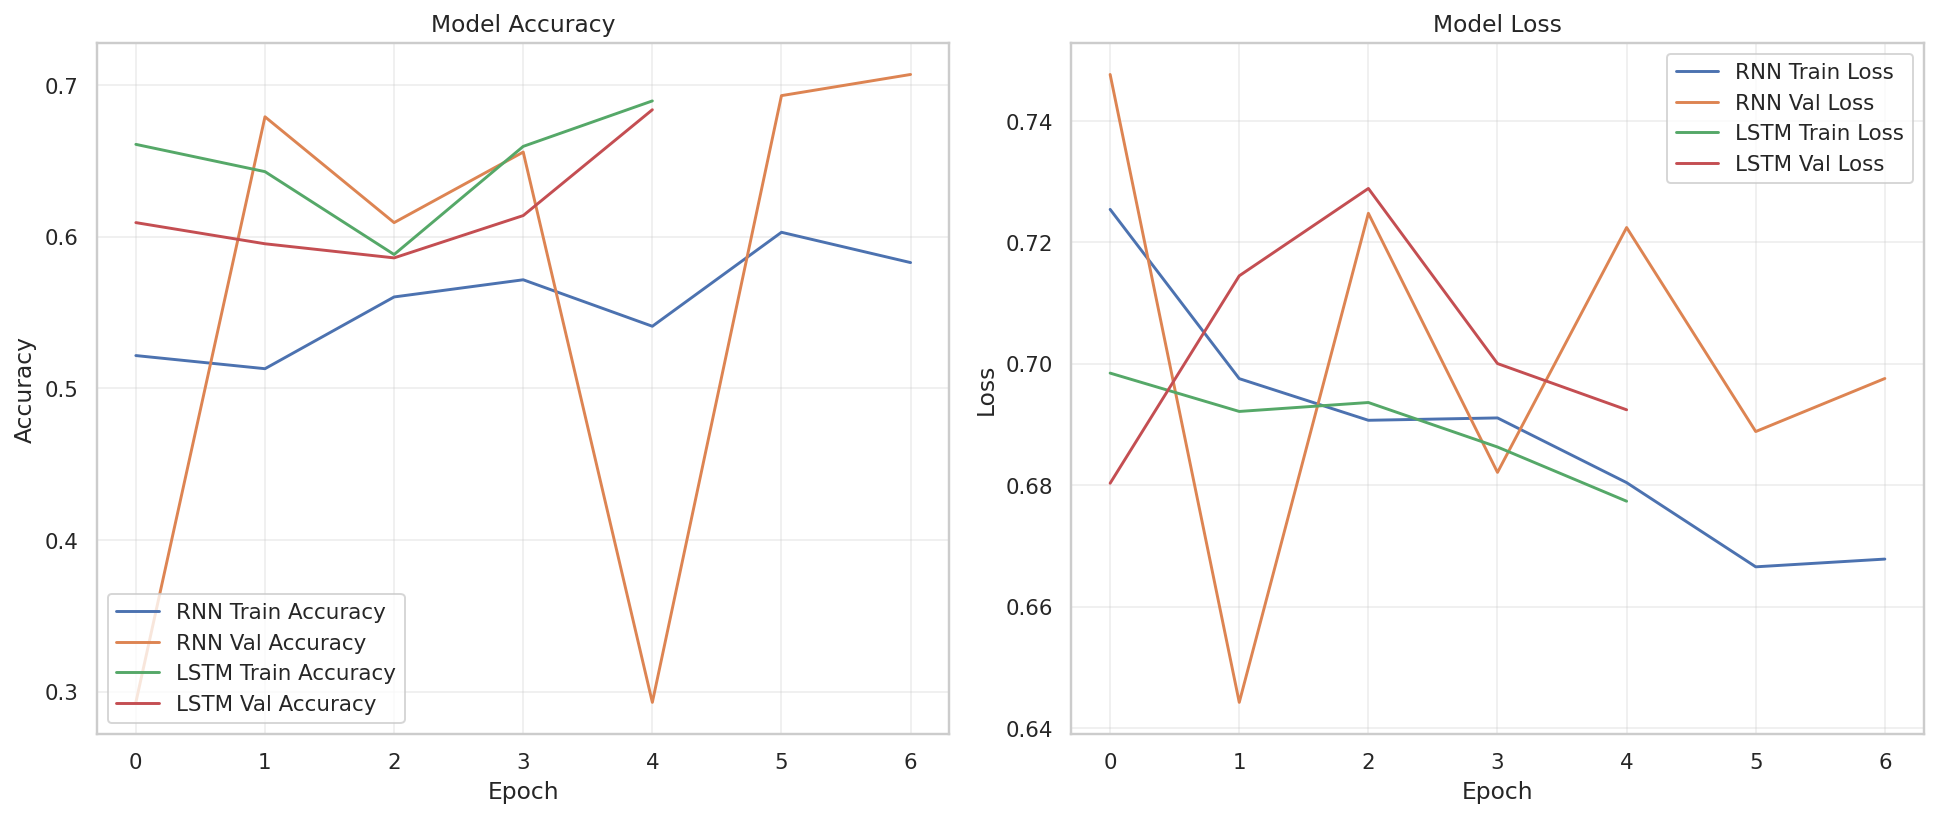

In [ ]:
lstm_model = build_lstm()
print(lstm_model.summary())
lstm_history = lstm_model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val),
                              epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
                              callbacks=callbacks, verbose=1)
plot_history(rnn_history, lstm_history) # Call plot_history after both models are trained

# Cell 11 – Evaluate on Test Set


In [ ]:
def metrics_table(model, X, y, name):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return pd.Series({
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y, y_prob)
    }), y_pred, y_prob

rnn_metrics, rnn_preds, rnn_probs = metrics_table(rnn_model, X_test_seq, y_test, 'RNN')
lstm_metrics, lstm_preds, lstm_probs = metrics_table(lstm_model, X_test_seq, y_test, 'LSTM')

results = pd.DataFrame([rnn_metrics, lstm_metrics])
print(results.to_string(index=False))


Model  Accuracy  Precision   Recall       F1  ROC-AUC
  RNN  0.644186   0.230769 0.247423 0.238806 0.476007
 LSTM  0.613953   0.248175 0.350515 0.290598 0.508359


# Cell 12 – Confusion Matrices


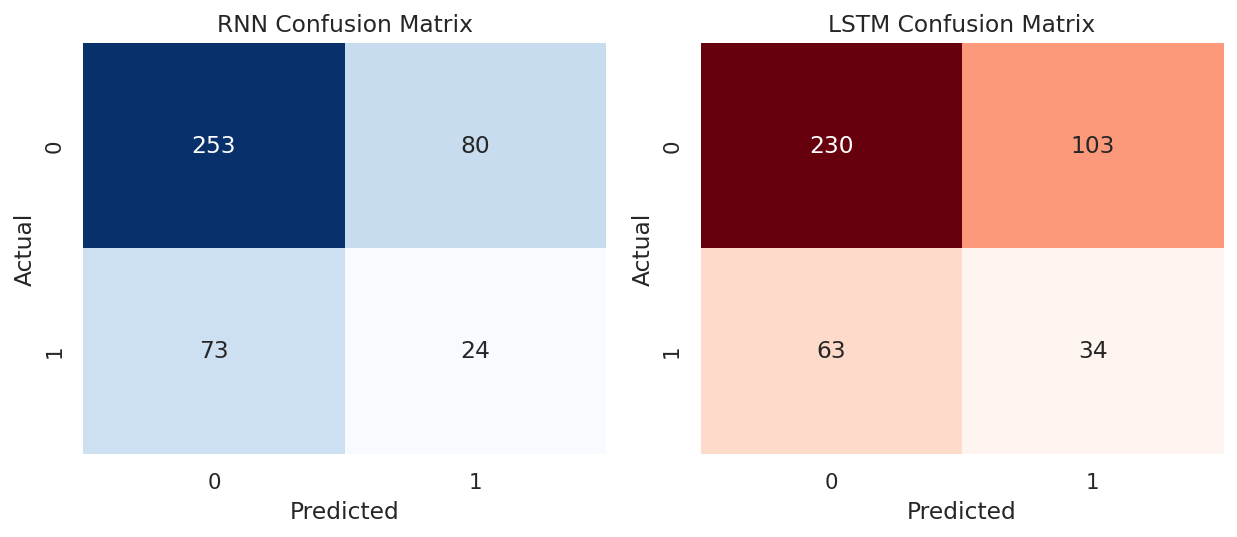

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
for ax, (name, preds, cmap) in zip(axes, [('RNN', rnn_preds, 'Blues'), ('LSTM', lstm_preds, 'Reds')]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


# Cell 13 – ROC Curves


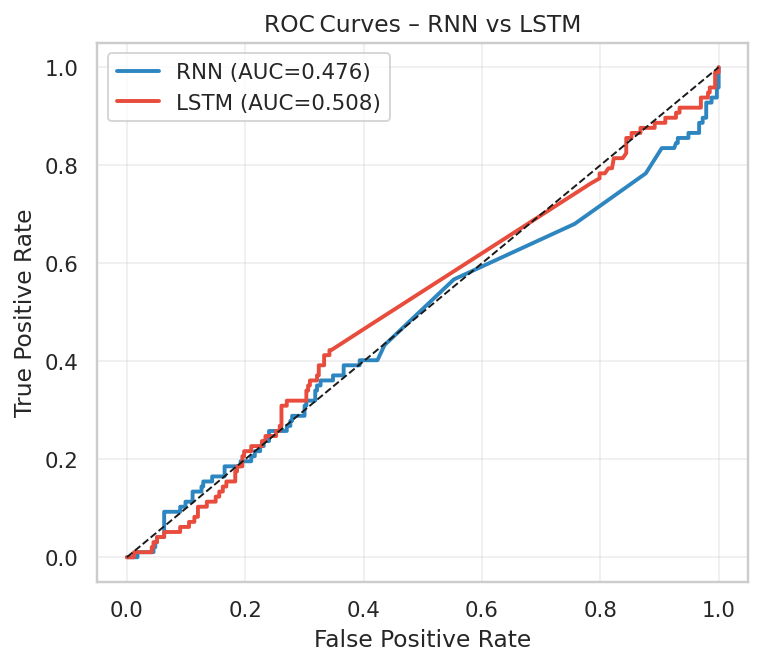

In [ ]:
plt.figure(figsize=(6,5))
for name, probs, color in [('RNN', rnn_probs, '#2E86C1'), ('LSTM', lstm_probs, '#E74C3C')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    aucv = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={aucv:.3f})', lw=2, color=color)
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves – RNN vs LSTM'); plt.legend(); plt.grid(alpha=0.3); plt.show()


# Cell 14 – Simple Error Analysis


In [ ]:
df_test = pd.DataFrame({
    'text': X_test, 'true': y_test,
    'rnn_pred': rnn_preds, 'lstm_pred': lstm_preds,
    'rnn_prob': rnn_probs, 'lstm_prob': lstm_probs
})

def show_examples(mask, title, n=3):
    sub = df_test[mask].head(n)
    print("\n" + title + "\n" + "="*len(title))
    for _, r in sub.iterrows():
        txt = r['text'][:250].replace('\n',' ')
        print(f"True:{r.true}  RNN:{r.rnn_pred}  LSTM:{r.lstm_pred}  →{txt}…")

show_examples((df_test.true==1)&(df_test.lstm_pred==0), 'FALSE NEGATIVES – Disputed but Predicted No')
show_examples((df_test.true==0)&(df_test.lstm_pred==1), 'FALSE POSITIVES – Not Disputed but Predicted Yes')




FALSE NEGATIVES – Disputed but Predicted No
True:1  RNN:0  LSTM:0  →i purchased a vehicle from drive time acceptance in due to their erroneous credit reporting all consumer trade lines had to be hidden removed from individual reports all of the consumers trade lines have been added but not consumers who ve had a bank…
True:1  RNN:0  LSTM:0  →shapiro dicaro barak was sent a notice demanding validation of a debt on via mail and personal service demanding shapiro dicaro barak validate the alleged debt they are collecting on shapiro dicaro barak refuses to validate the debt after carefully r…
True:1  RNN:0  LSTM:0  →this loan was taking care of and is still reporting it as unpaid and late…

FALSE POSITIVES – Not Disputed but Predicted Yes
True:0  RNN:1  LSTM:1  →i opened a checking account at bb t in sc in the terms of the account were no maintenance fees and i would receive paper bank statements within a short time about months the bank changed the terms so that to avoid a maintenance fe